### https://www.kaggle.com/competitions/drawing-with-llms

In [1]:
# import kagglehub
# import pandas as pd
# import re

# train_path = kagglehub.competition_download('drawing-with-llms', 'train.csv')
# train = pd.read_csv(train_path)

# train.head(2)

In [2]:
import openai
import pandas as pd
import time
import os
from dotenv import load_dotenv
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [3]:
from openai import OpenAI
client = OpenAI(api_key=deepseek_api_key, base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "You are a helpful assistant"},
        {"role": "user", "content": "Hello are you"},
    ],
    stream=False
)

print(response.choices[0].message.content)

Hello! Yes, I'm here and ready to help. How can I assist you today? 😊


In [4]:
# Set up OpenAI client with your AP
#client = openai.OpenAI(api_key=openai_api_key)

# Function to get summary from OpenAI API
def get_topic():
    instruction = f"""
    I am participating SVG code generation competition. 
    
    The competition test data comprises about 500 descriptions of everyday objects and scenes from a variety of domains. Your goal is to create a model that generates SVG depictions of these descriptions.
    The descriptions have the following properties:
    The descriptions are of common, generic subjects. No brand name or trademark or personal name occurs in any description. No people, even in generic form, occur in any description.
    The subjects described span about a dozen categories.  The remaining categories in the public and private sets are unique to each set. 
    No description has more than 200 characters. The average length is around 50 characters.   

   
    I am planing to generate syntetic data for my small LLM training. can you please give me 100 topics relavant to the competion above? 
    Each topic should have varying charater from 10 to 200 with 50 charater as average. Half of the topics should be from landscapes, abstract, and fashion.

    Please give your respose in csv format. do not include charater length in response. only give response. 
    """

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "Generate a topic"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.8,
            max_tokens=7200
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None


In [5]:
# Function to get summary from OpenAI API
def get_svg_code(text):
    instruction = f"""
            Generate SVG code to visually represent the following text description, while respecting the given constraints.
            <constraints>
            * **Allowed Elements:** `svg`, `path`, `circle`, `rect`, `ellipse`, `line`, `polyline`, `polygon`, `g`, `linearGradient`, `radialGradient`, `stop`, `defs`
            * **Allowed Attributes:** `viewBox`, `width`, `height`, `fill`, `stroke`, `stroke-width`, `d`, `cx`, `cy`, `r`, `x`, `y`, `rx`, `ry`, `x1`, `y1`, `x2`, `y2`, `points`, `transform`, `opacity`
            </constraints>

            Please ensure that the generated SVG code is well-formed, valid, and strictly adheres to these constraints. 
            Focus on a clear and concise representation of the input description within the given limitations. 
            Always give the complete SVG code with nothing omitted. Never use an ellipsis.

            input description: {text}
            """

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "Generate SVG code as per instruction"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.5,
            max_tokens=1024
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None

In [10]:
# #generate random topic for svg training date
# import csv
# from io import StringIO
# import re

# topics_list=[]
# for i in range(5):

#     response=get_topic()
#     response = re.sub(r"```", "", response)
#     print('##### Response ##########')
#     print(response)
#     print('\n')
    
#     # # Extracting topics using regex
#     # topics = re.findall(r'"(.*?)"', response)
#     # # Removing the header "Topic"
#     # topics = [t for t in topics if t.lower() != "topic"]
#     # topics_list.extend(topics)
    
#     # Read CSV and convert to a clean list
#     csv_file = StringIO(response)
#     reader = csv.reader(csv_file)
#     next(reader)  # Skip header
#     next(reader)  # Skip header
#     topics = [row[0] for row in reader]
#     topics_list.extend(topics)
   
# print(len(topics_list))

##### Response ##########
Here is a CSV-formatted list of 500 topics relevant to your SVG code generation competition, with a mix of landscapes, abstract concepts, and fashion items, along with other common objects and scenes:  

csv
"description"
"A serene lake surrounded by pine trees under a blue sky"
"Geometric patterns with intersecting triangles and circles"
"A red dress with a flowing skirt and lace sleeves"
"A cozy cabin nestled in a snowy forest"
"Abstract swirls of blue and green resembling ocean waves"
"A pair of high-heeled shoes with silver buckles"
"A desert landscape with cacti and a setting sun"
"Minimalist black and white stripes in a zigzag pattern"
"A denim jacket with patches and embroidery"
"A mountain range reflected in a still alpine lake"
"Fractal design with repeating hexagons in gold and black"
"A leather handbag with a tassel and metal clasp"
"A winding river through a lush green valley"
"Abstract splatter painting in vibrant reds and yellows"
"A wool scarf w

In [11]:
# # Writing to a text file
# topics_string = '\n'.join(topics_list)
# # Write to a text file
# with open("topics_train4.txt", "w") as file:
#     file.write(topics_string)

In [26]:
import pandas as pd
df1 = pd.read_table("topics_train3.txt", header=None)
df1.columns = ["topic"]
print(df1.shape)

df2 = pd.read_table("topics_train4.txt", header=None)
df2.columns = ["topic"]
print(df2.shape)

df=pd.concat([df1, df2], ignore_index=True)
print(df.shape)

df = df.sample(n=2000, random_state=42) 
print(df.shape)

(846, 1)
(4785, 1)
(5631, 1)
(2000, 1)


In [27]:
df

,topic
3135,A wooden gate in a country lane
1835,A vintage typewriter with keys slightly worn
3832,A quiet vineyard with rows of grapevines
1919,A wooden barrel with metal hoops
4418,A smooth gradient of warm oranges
...,...
4463,A smooth gradient of deep forest greens
156,Abstract ink strokes resembling waves
3753,A bohemian-style maxi dress with fringe details
2404,A silk hair clip


In [28]:
from tqdm import tqdm
tqdm.pandas() 
df["response"] = df["topic"].progress_apply(get_svg_code)

100%|████████████████████████████████████| 2000/2000 [14:10:56<00:00, 25.53s/it]


In [29]:
df.to_csv('response_train3.csv',index=False)

In [30]:
import re
def clean_svg(text):
    svg_code = re.search(r'```xml\n(.*?)\n```', text, re.DOTALL)
    
    if svg_code:
        extracted_svg = svg_code.group(1)
        return extracted_svg
    else:
        return '<svg </svg>'

In [31]:
df["svg_code"] = df["response"].progress_apply(clean_svg)

100%|███████████████████████████████████| 2000/2000 [00:00<00:00, 136066.05it/s]


In [32]:
df['svg_code'].iloc[0]

'<svg viewBox="0 0 200 150" width="400" height="300" xmlns="http://www.w3.org/2000/svg">\n  <defs>\n    <linearGradient id="wood" x1="0%" y1="0%" x2="100%" y2="0%">\n      <stop offset="0%" stop-color="#8B4513" />\n      <stop offset="50%" stop-color="#A0522D" />\n      <stop offset="100%" stop-color="#8B4513" />\n    </linearGradient>\n    <linearGradient id="ground" x1="0%" y1="0%" x2="0%" y2="100%">\n      <stop offset="0%" stop-color="#228B22" />\n      <stop offset="100%" stop-color="#556B2F" />\n    </linearGradient>\n  </defs>\n\n  <!-- Background -->\n  <rect x="0" y="0" width="200" height="150" fill="skyblue" />\n  <rect x="0" y="100" width="200" height="50" fill="url(#ground)" />\n\n  <!-- Country lane path -->\n  <path d="M0 120 Q100 80 200 120" fill="none" stroke="#D2B48C" stroke-width="15" />\n\n  <!-- Wooden gate -->\n  <g transform="translate(80, 70)">\n    <!-- Gate posts -->\n    <rect x="-5" y="0" width="10" height="60" fill="url(#wood)" />\n    <rect x="45" y="0" wid

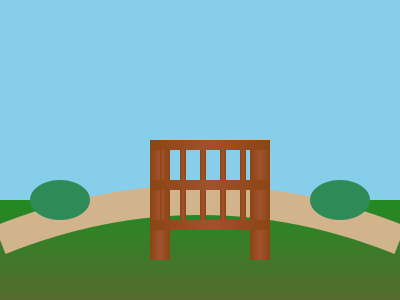

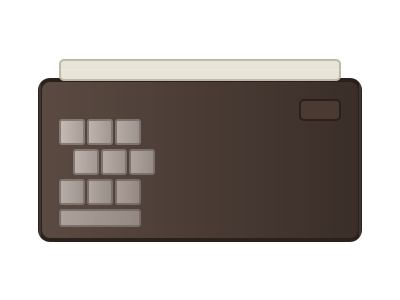

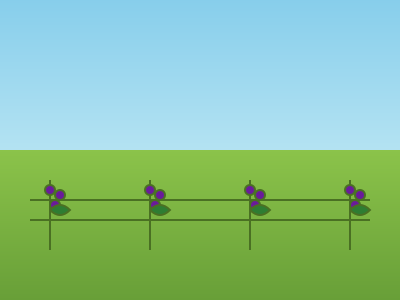

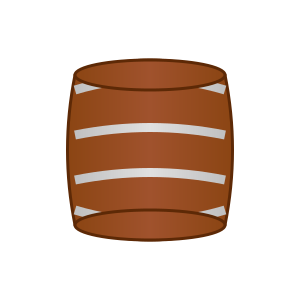

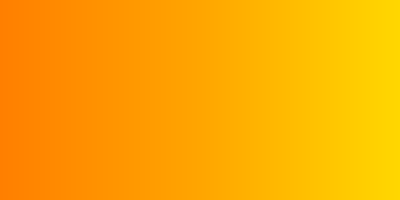

ExpatError: not well-formed (invalid token): line 1, column 5

In [33]:
# We can play with our Model and render its SVG output (don't export!)
from IPython.display import SVG, display
for svg in df["svg_code"].iloc[:10]:
    #print(svg)
    display(SVG(svg))

In [34]:
from transformers import AutoProcessor, AutoModel
model = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")
processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

In [35]:
import torch
from PIL import Image
import cairosvg
import os

def svgMetric(prompt, svg):
    try:
        # Convert SVG to PNG
        cairosvg.svg2png(svg, write_to="./tmp/temp.png")
        
        # Open and process the image
        image = Image.open('./tmp/temp.png').convert("RGB")
        texts = ["SVG illustration of " + prompt]
        inputs = processor(text=texts, images=image, padding="max_length", return_tensors="pt")
        
        # Inference without gradient tracking
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits_per_image = outputs.logits_per_image
        probs = torch.sigmoid(logits_per_image)
        
        # Clean up temporary PNG file
        #os.remove('./tmp/temp.png')
        
        return probs[0][0].item()

    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None




In [36]:
# Using apply to process each row in the DataFrame
df['score'] = df.progress_apply(lambda row: svgMetric(row['topic'], row['svg_code']), axis=1)


  0%|▏                                         | 6/2000 [00:10<55:14,  1.66s/it]

An error occurred: not well-formed (invalid token): line 1, column 5


  0%|▏                                         | 8/2000 [00:12<42:53,  1.29s/it]

An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5


  1%|▎                                        | 13/2000 [00:17<38:22,  1.16s/it]

...

 99%|██████████████████████████████████████▊| 1988/2000 [23:25<00:06,  1.73it/s]

An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5


100%|██████████████████████████████████████▊| 1992/2000 [23:28<00:05,  1.44it/s]

An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5
An error occurred: not well-formed (invalid token): line 1, column 5


100%|███████████████████████████████████████| 2000/2000 [23:31<00:00,  1.42it/s]


In [37]:
# Display results
print('mean gpt-4o score:',df['score'].mean())

mean gpt-4o score: 0.57221991802494


In [38]:
df.to_csv('svg_score_train3.csv',index=False)

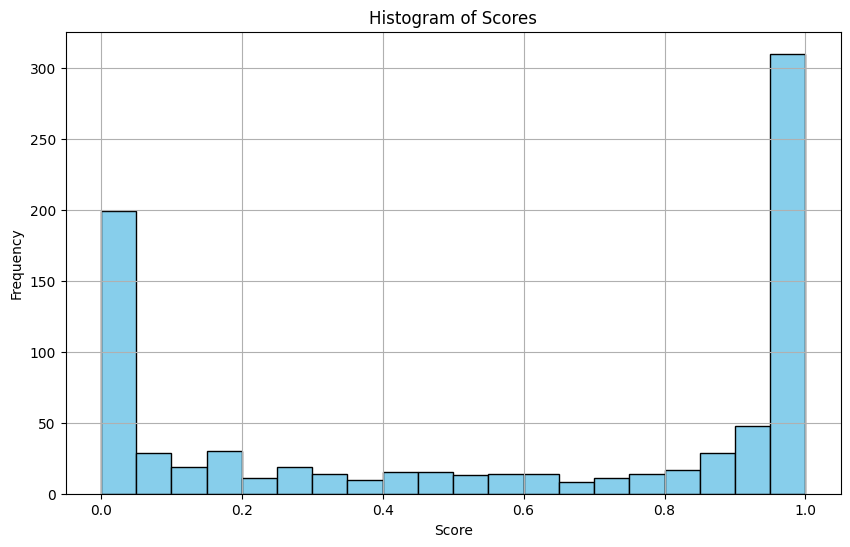

In [39]:
import matplotlib.pyplot as plt

# Plot histogram of the 'score' column
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [40]:
count = (df['score'] > 0.6).sum()
print(f"Number of entries with score > 0.6: {count}")

Number of entries with score > 0.6: 451
